# Caracterització de la transició de fase de no equilibri de la dinàmica SIS en grafs aleatoris

Aquest notebook implementa el **mètode del *lifespan*** per al procés SIS en grafs aleatoris del model de configuració amb distribució de graus de llei de potències.
Aquest notebook genera les dades i ploteja de manera orientativa. Els plots bons per al report estan al notebook FINAL


1. Xarxes del model de configuració amb $P(k)\propto k^{-\gamma}$, $k_{\min}=4$, $\gamma=3.5$ i $\gamma=2.5$, i diverses mides $N$.
2. Dinàmica SIS de Gillespie que arrenca des d'un únic node infectat de grau mínim $4$.
3. Mesura de:
   $$
   P_{\rm end}(\lambda,N), \qquad \langle \tau(\lambda,N)\rangle
   $$
   usant un llindar de cobertura de $N/2$.
4. Estimacions de mida finita de $\lambda_c$, $1/\nu$, $\gamma_1/\nu$ i $\beta/\nu$.


## 0. Decisions de disseny per a l'eficiència

Per a $N\sim 10^6$, la simulació ha d'evitar totes les operacions $O(N)$ o $O(E)$ dins del bucle d'esdeveniments.

La implementació següent utilitza:

- Representació d'adjacència CSR: `indptr`, `indices`, `edge_ids`
- un `edge_id` únic per a cada aresta no dirigida
- llista de nodes infectats: `inf_nodes[0:NI]`, `pos_inf[node]`
- llista d'enllaços actius: `active_inf[0:Eact]`, `active_sus[0:Eact]`, `active_eid[0:Eact]`, `pos_active[edge_id]`

Així, la recuperació aleatòria és $O(1)$, la infecció aleatòria a través d'un enllaç actiu escollit uniformement és $O(1)$, i l'actualització d'estat després d'una infecció o recuperació és $O(k_i)$, on $k_i$ és el grau del node l'estat del qual ha canviat.

In [ ]:

import os
import gc
import json
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except Exception:
    NUMBA_AVAILABLE = False
    warnings.warn("Numba is not available. Install numba for the fast Gillespie kernel.")

RESULTS_DIR = Path("sis_results/adaptive_boost")
GRAPH_DIR = RESULTS_DIR / "adaptive_10K/graphs"
SCAN_DIR = RESULTS_DIR / "adaptive_10K/scans"
FIG_DIR = RESULTS_DIR / "adaptive_10K/figures"

for d in [RESULTS_DIR, GRAPH_DIR, SCAN_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BASE_SEED = 12345
rng_global = np.random.default_rng(BASE_SEED)

print(f"Numba available: {NUMBA_AVAILABLE}")
print(f"Results directory: {RESULTS_DIR.resolve()}")

# Estil "paper" pels plots (serif, sense spines dalt/dreta) i paleta
# colorblind-friendly (magma) en comptes del cicle de colors per defecte.
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.6,
    "lines.markersize": 4,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "savefig.bbox": "tight",
})

def n_color_map(n_values):
    """Un color de magma per cada N, sempre el mateix N -> mateix color.
    Evito els extrems de la paleta (massa fosc/massa clar) perque es vegin
    be sobre fons blanc."""
    n_sorted = sorted(set(int(n) for n in n_values))
    shades = plt.cm.magma(np.linspace(0.85, 0.15, len(n_sorted)))
    return {n: shades[i] for i, n in enumerate(n_sorted)}

ACCENT = plt.cm.magma(0.45)

def clean_ax(ax=None):
    """Treu les spines de dalt i de la dreta -- aspecte "paper"."""
    ax = ax or plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

Numba available: True
Results directory: C:\Users\labor\Desktop\ComplexNetworks\sis_lifespan_assignment_package\sis_results\adaptive_boost


## 1. Generador de grafs del model de configuració


$$
P(k)\propto k^{-\gamma}, \qquad k\ge k_{\min}=4.
$$

Per a $N$ gran, un graf complet de NetworkX és massa pesat en memòria. Generem la llista d'stubs directament amb NumPy, aparellem els stubs aleatòriament, descartem els automarcles i traiem les arestes paraleles amb remove_parallel = True


In [28]:

def sample_powerlaw_degrees(
    N,
    gamma,
    kmin=4,
    rng=None,
    cutoff="natural",
    force_even=True,
    dtype=np.int32,
):
    """
    Sample integer degrees from an approximate discrete power law.

    cutoff:
    - "natural": kmax ~ N^(1/(gamma-1))
    - "structural": kmax ~ sqrt(N)
    - int: explicit maximum degree
    - None: no explicit cutoff, except k <= N-1
    """
    if rng is None:
        rng = np.random.default_rng()

    u = rng.random(N)
    deg = np.floor(kmin * (1.0 - u) ** (-1.0 / (gamma - 1.0))).astype(np.int64)

    if cutoff == "natural":
        kmax = int(min(N - 1, max(kmin, N ** (1.0 / (gamma - 1.0)))))
    elif cutoff == "structural":
        kmax = int(min(N - 1, max(kmin, np.sqrt(N))))
    elif cutoff is None:
        kmax = N - 1
    else:
        kmax = int(cutoff)

    deg = np.clip(deg, kmin, kmax)

    if force_even and (deg.sum() % 2 == 1):
        idx = rng.integers(0, N)
        if deg[idx] < kmax:
            deg[idx] += 1
        else:
            deg[idx] -= 1

    return deg.astype(dtype)

def configuration_model_edges(
    degrees,
    rng=None,
    remove_selfloops=True,
    remove_parallel=True,
    dtype=np.int32,
):
    """
    Construct undirected edges from a degree sequence using random stub pairing.

    Parallel edges are kept by default because this is the genuine multigraph
    configuration model and avoids expensive de-duplication.
    """
    if rng is None:
        rng = np.random.default_rng()

    N = len(degrees)
    m2 = int(np.sum(degrees))
    if m2 % 2 != 0:
        raise ValueError("Degree sum must be even.")

    stubs = np.repeat(np.arange(N, dtype=dtype), degrees.astype(np.int64))
    rng.shuffle(stubs)

    u = stubs[0::2].astype(dtype, copy=False)
    v = stubs[1::2].astype(dtype, copy=False)
    del stubs

    if remove_selfloops:
        mask = u != v
        u = u[mask]
        v = v[mask]

    if remove_parallel:
        a = np.minimum(u, v).astype(np.int64)
        b = np.maximum(u, v).astype(np.int64)
        pairs = np.column_stack((a, b))
        pairs = np.unique(pairs, axis=0)
        u = pairs[:, 0].astype(dtype)
        v = pairs[:, 1].astype(dtype)

    return u.astype(dtype, copy=False), v.astype(dtype, copy=False)

def edges_to_csr(N, edge_u, edge_v, dtype=np.int32):
    """
    Convert an undirected edge list into CSR arrays with edge ids.
    """
    M = len(edge_u)
    edge_ids_unique = np.arange(M, dtype=dtype)

    src = np.concatenate([edge_u, edge_v]).astype(dtype, copy=False)
    dst = np.concatenate([edge_v, edge_u]).astype(dtype, copy=False)
    eid = np.concatenate([edge_ids_unique, edge_ids_unique]).astype(dtype, copy=False)

    order = np.argsort(src, kind="mergesort")
    src_sorted = src[order]
    indices = dst[order].astype(dtype, copy=False)
    edge_ids = eid[order].astype(dtype, copy=False)

    counts = np.bincount(src_sorted, minlength=N).astype(np.int64)
    indptr = np.empty(N + 1, dtype=np.int64)
    indptr[0] = 0
    np.cumsum(counts, out=indptr[1:])

    return indptr, indices, edge_ids, edge_u.astype(dtype), edge_v.astype(dtype)

def generate_configuration_powerlaw_graph(
    N,
    gamma,
    kmin=4,
    seed=0,
    cutoff="natural",
    remove_parallel=True,
    save_path=None,
):
    """
    Generate and optionally save a configuration-model graph in CSR format.
    """
    rng = np.random.default_rng(seed)

    t0 = time.time()
    degrees = sample_powerlaw_degrees(N, gamma, kmin=kmin, rng=rng, cutoff=cutoff)
    edge_u, edge_v = configuration_model_edges(
        degrees,
        rng=rng,
        remove_selfloops=True,
        remove_parallel=remove_parallel,
    )
    indptr, indices, edge_ids, edge_u, edge_v = edges_to_csr(N, edge_u, edge_v)

    realized_degree = np.diff(indptr).astype(np.int32)
    min_degree_nodes = np.flatnonzero(realized_degree == kmin).astype(np.int32)

    if len(min_degree_nodes) == 0:
        raise RuntimeError(
            "No nodes of realized degree kmin after self-loop removal. "
            "Try regenerating, using original-degree seed nodes, or changing cutoff."
        )

    meta = {
        "N": int(N),
        "gamma": float(gamma),
        "kmin": int(kmin),
        "M": int(len(edge_u)),
        "mean_degree_realized": float(realized_degree.mean()),
        "max_degree_realized": int(realized_degree.max()),
        "n_min_degree_nodes": int(len(min_degree_nodes)),
        "cutoff": str(cutoff),
        "remove_parallel": bool(remove_parallel),
        "seed": int(seed),
        "generation_seconds": float(time.time() - t0),
    }

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(
            save_path,
            indptr=indptr,
            indices=indices,
            edge_ids=edge_ids,
            edge_u=edge_u,
            edge_v=edge_v,
            min_degree_nodes=min_degree_nodes,
            realized_degree=realized_degree,
            meta=json.dumps(meta),
        )

    return indptr, indices, edge_ids, edge_u, edge_v, min_degree_nodes, meta

def load_graph_npz(path):
    data = np.load(path, allow_pickle=False)
    meta = json.loads(str(data["meta"]))
    return (
        data["indptr"],
        data["indices"],
        data["edge_ids"],
        data["edge_u"],
        data["edge_v"],
        data["min_degree_nodes"],
        data["realized_degree"],
        meta,
    )

## 2. Nucli de Gillespie SIS amb gestió d'enllaços actius

La taxa total és
$$
R(t)=\delta N_I(t)+\lambda E_{\rm act}(t),
$$
amb $\delta=1$. Per tant:
$$
P(\text{infecció})=\frac{\lambda E_{\rm act}}{N_I+\lambda E_{\rm act}},
\qquad
P(\text{recuperació})=\frac{N_I}{N_I+\lambda E_{\rm act}}.
$$

Una realització s'atura quan:

- el brot assoleix la cobertura $C\ge N/2$: realització endèmica;
- no queden nodes infectats: realització no endèmica, *lifespan* $\tau$;
- s'assoleix el límit de seguretat `max_events`: tractada com a

In [29]:

if NUMBA_AVAILABLE:

    @njit
    def _remove_active(eid, Eact, active_inf, active_sus, active_eid, pos_active):
        pos = pos_active[eid]
        if pos == -1:
            return Eact

        last = Eact - 1
        last_eid = active_eid[last]

        active_inf[pos] = active_inf[last]
        active_sus[pos] = active_sus[last]
        active_eid[pos] = last_eid
        pos_active[last_eid] = pos

        pos_active[eid] = -1
        return last

    @njit
    def _add_active(inf, sus, eid, Eact, active_inf, active_sus, active_eid, pos_active):
        if pos_active[eid] != -1:
            return Eact

        active_inf[Eact] = inf
        active_sus[Eact] = sus
        active_eid[Eact] = eid
        pos_active[eid] = Eact
        return Eact + 1

    @njit
    def sis_lifespan_batch_numba(
        indptr,
        indices,
        edge_ids,
        min_degree_nodes,
        lam,
        n_runs,
        coverage_threshold,
        seed,
        max_events,
        treat_max_events_as_endemic=True,
    ):
        """
        Run many SIS lifespan realizations on one fixed graph and one lambda.
        """
        np.random.seed(seed)

        N = len(indptr) - 1
        M = int(np.max(edge_ids)) + 1

        infected = np.zeros(N, dtype=np.uint8)
        ever = np.zeros(N, dtype=np.uint8)

        inf_nodes = np.empty(N, dtype=np.int32)
        pos_inf = np.empty(N, dtype=np.int32)

        ever_nodes = np.empty(N, dtype=np.int32)

        active_inf = np.empty(M, dtype=np.int32)
        active_sus = np.empty(M, dtype=np.int32)
        active_eid = np.empty(M, dtype=np.int32)
        pos_active = np.empty(M, dtype=np.int32)
        pos_active[:] = -1

        endemic_flags = np.zeros(n_runs, dtype=np.uint8)
        lifespans = np.empty(n_runs, dtype=np.float64)
        lifespans[:] = np.nan
        coverages = np.zeros(n_runs, dtype=np.int64)
        event_counts = np.zeros(n_runs, dtype=np.int64)

        n_seed_candidates = len(min_degree_nodes)

        for run in range(n_runs):
            seed_node = min_degree_nodes[np.random.randint(0, n_seed_candidates)]

            t = 0.0
            NI = 1
            Eact = 0
            coverage = 1
            events = 0

            infected[seed_node] = 1
            ever[seed_node] = 1
            inf_nodes[0] = seed_node
            pos_inf[seed_node] = 0
            ever_nodes[0] = seed_node

            for p in range(indptr[seed_node], indptr[seed_node + 1]):
                sus = indices[p]
                eid = edge_ids[p]
                if sus != seed_node:
                    Eact = _add_active(seed_node, sus, eid, Eact, active_inf, active_sus, active_eid, pos_active)

            while NI > 0 and coverage < coverage_threshold and events < max_events:
                rate = NI + lam * Eact
                if rate <= 0.0:
                    break

                xi = np.random.random()
                while xi <= 0.0:
                    xi = np.random.random()
                t += -math.log(xi) / rate

                if np.random.random() < (lam * Eact) / rate and Eact > 0:
                    aidx = np.random.randint(0, Eact)
                    v = active_sus[aidx]  # susceptible endpoint becomes infected

                    if infected[v] == 0:
                        infected[v] = 1
                        inf_nodes[NI] = v
                        pos_inf[v] = NI
                        NI += 1

                        if ever[v] == 0:
                            ever[v] = 1
                            ever_nodes[coverage] = v
                            coverage += 1

                        for p in range(indptr[v], indptr[v + 1]):
                            u = indices[p]
                            eid = edge_ids[p]

                            if infected[u] == 1:
                                Eact = _remove_active(eid, Eact, active_inf, active_sus, active_eid, pos_active)
                            else:
                                Eact = _add_active(v, u, eid, Eact, active_inf, active_sus, active_eid, pos_active)

                else:
                    # Recovery of a uniformly chosen infected node.
                    ridx = np.random.randint(0, NI)
                    v = inf_nodes[ridx]

                    for p in range(indptr[v], indptr[v + 1]):
                        u = indices[p]
                        eid = edge_ids[p]

                        if infected[u] == 1:
                            Eact = _add_active(u, v, eid, Eact, active_inf, active_sus, active_eid, pos_active)
                        else:
                            Eact = _remove_active(eid, Eact, active_inf, active_sus, active_eid, pos_active)

                    infected[v] = 0

                    last = NI - 1
                    last_node = inf_nodes[last]
                    inf_nodes[ridx] = last_node
                    pos_inf[last_node] = ridx
                    NI = last

                events += 1

            if coverage >= coverage_threshold:
                endemic_flags[run] = 1
            elif events >= max_events and treat_max_events_as_endemic:
                endemic_flags[run] = 1
            else:
                endemic_flags[run] = 0
                lifespans[run] = t

            coverages[run] = coverage
            event_counts[run] = events

            # Clean only touched arrays, not all N or all M.
            for i in range(NI):
                node = inf_nodes[i]
                infected[node] = 0

            for i in range(coverage):
                node = ever_nodes[i]
                ever[node] = 0

            for i in range(Eact):
                eid = active_eid[i]
                pos_active[eid] = -1

        return endemic_flags, lifespans, coverages, event_counts

def sis_lifespan_batch(
    indptr,
    indices,
    edge_ids,
    min_degree_nodes,
    lam,
    n_runs,
    coverage_threshold,
    seed,
    max_events,
):
    """
    Thin Python wrapper around the numba kernel.
    """
    if not NUMBA_AVAILABLE:
        raise RuntimeError("This notebook requires numba for the efficient SIS kernel.")
    return sis_lifespan_batch_numba(
        indptr.astype(np.int64, copy=False),
        indices.astype(np.int32, copy=False),
        edge_ids.astype(np.int32, copy=False),
        min_degree_nodes.astype(np.int32, copy=False),
        float(lam),
        int(n_runs),
        int(coverage_threshold),
        int(seed),
        int(max_events),
    )

def summarize_lifespan_runs(endemic_flags, lifespans, coverages, event_counts):
    """
    Convert raw run arrays into assignment observables.
    """
    n_runs = len(endemic_flags)
    n_end = int(endemic_flags.sum())
    non_end = endemic_flags == 0

    if non_end.sum() > 0:
        tau_mean = float(np.nanmean(lifespans[non_end]))
        tau_std = float(np.nanstd(lifespans[non_end], ddof=1)) if non_end.sum() > 1 else np.nan
        tau_se = tau_std / math.sqrt(int(non_end.sum())) if non_end.sum() > 1 else np.nan
    else:
        tau_mean = np.nan
        tau_std = np.nan
        tau_se = np.nan

    p = n_end / n_runs
    p_se = math.sqrt(p * (1.0 - p) / n_runs) if n_runs > 0 else np.nan

    return {
        "n_runs": int(n_runs),
        "n_endemic": int(n_end),
        "n_nonendemic": int(non_end.sum()),
        "P_end": float(p),
        "P_end_se": float(p_se),
        "tau_mean": tau_mean,
        "tau_std": tau_std,
        "tau_se": tau_se,
        "coverage_mean": float(np.mean(coverages)),
        "events_mean": float(np.mean(event_counts)),
        "events_max": int(np.max(event_counts)),
    }

## 3. Simulació (graella adaptativa + calibració)


2. **Scan adaptatiu.** `run_scan()` usa per defecte `adaptive_lambda_grid(gamma, N)`: ~42 lambdes centrades al pic estimat de cada $(\gamma, N)$ (30 denses + flancs), en lloc de 70 repartides uniformement per $[0.005, 0.35]$. Això concentra tota la resolució on hi ha el pic i estalvia ~40% del cost (molt més per a $\gamma=2.5$, on el pic és a $\lambda\lesssim 0.04$ i la graella uniforme malgastava la majoria de runs a $\lambda>0.15$, tot endèmic).


In [41]:
# User parameters, calibracio del pic i graella adaptativa

SMOKE_TEST = False

GAMMAS = [2.5] # falta 3.5
KMIN = 4
REMOVE_PARALLEL = True
CUTOFF = "natural"

if SMOKE_TEST:
    N_VALUES = [2_000, 5_000, 10_000]
    N_RUNS = 200
    MAX_EVENTS_FACTOR = 50
else:
    N_VALUES = [10_000, 30_000, 50_000, 100_000, 300_000, 500_000, 1_000_000]
    N_RUNS = 50000
    MAX_EVENTS_FACTOR = 200

# Mida petita per calibrar (barata -> pots posar moltissims runs)
N_CALIBRATION = 2_000
N_RUNS_CALIBRATION = 40_000

def calibrate_peak(gamma, N_cal=N_CALIBRATION, n_runs=N_RUNS_CALIBRATION,
                   lam_lo=0.01, lam_hi=0.30, n_pts=25, evfac=80, seed=2024):
    """
    Localitza el pic de <tau> per a la xarxa MES PETITA amb molta estadistica.

    Idea fisica: lambda_p(N) decreix monotonament amb N (s'acosta a lambda_c
    per dalt com N^{-1/nu}). Per tant el pic de la xarxa mes petita es el
    lambda_p MAXIM i marca el limit superior de la finestra per a totes les
    mides mes grans. N petita es barata: ~40k runs donen un pic net (amb
    2000 runs el pic queda enterrat en soroll).

    Retorna (lambda_p_max, taula(lam, tau, Pend)).
    """
    graph_seed = BASE_SEED + int(1000 * gamma) + N_cal
    *graph, meta = generate_configuration_powerlaw_graph(
        N=N_cal, gamma=gamma, kmin=KMIN, seed=graph_seed,
        cutoff=CUTOFF, remove_parallel=REMOVE_PARALLEL)
    indptr, indices, edge_ids, edge_u, edge_v, min_deg = graph
    cov_thr = N_cal // 2
    max_events = evfac * N_cal

    grid = np.linspace(lam_lo, lam_hi, n_pts)
    rows = []
    for lam in grid:
        ef, tau, cov, ec = sis_lifespan_batch(
            indptr, indices, edge_ids, min_deg, lam=float(lam), n_runs=n_runs,
            coverage_threshold=cov_thr, seed=seed + int(lam * 1e6),
            max_events=max_events)
        ne = ef == 0
        rows.append((lam, float(np.nanmean(tau[ne])) if ne.sum() else np.nan, float(ef.mean())))
    arr = np.array(rows)
    i = int(np.nanargmax(arr[:, 1]))
    return float(arr[i, 0]), arr

# Pics calibrats. Valors per defecte: calibracio amb 40k runs a N=2000,
# mes la tendencia observada del primer scan a N grans.
#   gamma=3.5 : pic net a lam=0.150 (N=2000), baixant cap a ~0.107 (N=1e6)
#   gamma=2.5 : pic net a lam=0.040 (N=2000), baixant rapid cap a <0.01
# Per refrescar:  lp, _ = calibrate_peak(3.5);  PEAK_ESTIMATES[3.5][2000] = lp
PEAK_ESTIMATES = {
    3.5: {
        10_000:    0.120,
        30_000:    0.118,
        50_000:    0.115,
        100_000:   0.112,
        300_000:   0.110,
        500_000:   0.108,
        1_000_000: 0.107,
    },
   2.5: {
        10_000:    0.022,
        30_000:    0.02,
        50_000:    0.018,
        100_000:   0.015,
        300_000:   0.015,
        500_000:   0.014,
        1_000_000: 0.013,
    },
}

def _interp_peak(gamma, N):
    peaks = PEAK_ESTIMATES.get(gamma, {})
    Ns_k = np.array(sorted(peaks.keys()), float)
    lps_k = np.array([peaks[n] for n in sorted(peaks.keys())], float)
    return float(np.interp(np.log(float(N)), np.log(Ns_k), lps_k))

# Finestres refinades per mida, basades en el scan exploratori

REFINED_WINDOWS = {
    3.5: {
        10_000:    (0.087, 0.14, 50),
        30_000:    (0.087, 0.13, 50),
        50_000:    (0.087, 0.125, 50),
        100_000:   (0.087, 0.115, 50),
        300_000:   (0.087, 0.105, 50),
        500_000:   (0.087, 0.102, 20),
        1_000_000: (0.087, 0.099, 20),
    },

    2.5: {
        10_000:    (0.005, 0.028, 50),
        30_000:    (0.005, 0.0185, 50),
        50_000:    (0.005, 0.015, 50),
        100_000:   (0.005, 0.013, 50),
        300_000:   (0.005, 0.009, 20),
        500_000:   (0.005, 0.0085, 20),
        1_000_000: (0.005, 0.007, 20),
    },
}

def adaptive_lambda_grid(gamma, N, half_window=None, n_dense=30, n_flank=6,
                         lam_p_max=None):
    """
    Graella refinada per a cada parella (gamma, N).

    Ara ja no fem una finestra ampla global.
    Fem servir els scans exploratoris per definir una finestra curta
    al voltant del pic de <tau(lambda,N)>.
    """

    if gamma not in REFINED_WINDOWS:
        raise ValueError(f"No refined window defined for gamma={gamma}")

    if N not in REFINED_WINDOWS[gamma]:
        raise ValueError(f"No refined window defined for gamma={gamma}, N={N}")

    lam_min, lam_max, n_points = REFINED_WINDOWS[gamma][N]

    return np.round(np.linspace(lam_min, lam_max, n_points), 6)

# def adaptive_lambda_grid(gamma, N, half_window=None, n_dense=30, n_flank=6,
#                          lam_p_max=None):

#     peaks = PEAK_ESTIMATES.get(gamma, {})
#     if len(peaks) == 0:
#         return np.linspace(0.005, 0.35, 50)

#     lp = float(np.clip(_interp_peak(gamma, N), 0.003, 0.30))

#     if half_window is None:
#         half_window = 0.025 if gamma >= 3.0 else 0.006

#     lam_max_cap = 0.140 if gamma >= 3.0 else 0.026

#     lo = max(0.002, lp - half_window)
#     hi = min(lam_max_cap, lp + half_window)

#     if lam_p_max is not None:
#         hi = min(hi, lam_p_max * 1.10)

#     dense = np.linspace(lo, hi, n_dense)

#     lo_f = max(0.001, lp - 2.5 * half_window)
#     hi_f = min(lam_max_cap, lp + 2.5 * half_window)

#     if lam_p_max is not None:
#         hi_f = min(hi_f, lam_p_max * 1.10)

#     left_f = np.linspace(lo_f, lo, n_flank + 1)[:-1]
#     right_f = np.linspace(hi, hi_f, n_flank + 1)[1:]

#     grid = np.unique(np.round(np.concatenate([left_f, dense, right_f]), 6))
#     return grid

# Resum de les graelles que s'usaran
if not SMOKE_TEST:
    header = "{:>6} {:>9} {:>6} {:>8} {:>8} {:>8}".format(
        "gamma", "N", "n_pts", "lam_min", "lp_est", "lam_max")
    print(header)
    print("-" * 55)
    for _g in GAMMAS:
        for _N in N_VALUES:
            _gr = adaptive_lambda_grid(_g, _N)
            _lp = _interp_peak(_g, _N)
            print("{:>6.1f} {:>9,} {:>6} {:>8.4f} {:>8.4f} {:>8.4f}".format(
                _g, _N, len(_gr), _gr.min(), _lp, _gr.max()))
print("N_RUNS:", N_RUNS, "| Calibrar:  lp,_ = calibrate_peak(3.5); print(lp)")

 gamma         N  n_pts  lam_min   lp_est  lam_max
-------------------------------------------------------
   2.5    10,000     50   0.0050   0.0220   0.0280
   2.5    30,000     50   0.0050   0.0200   0.0185
   2.5    50,000     50   0.0050   0.0180   0.0150
   2.5   100,000     50   0.0050   0.0150   0.0130
   2.5   300,000     20   0.0050   0.0150   0.0090
   2.5   500,000     20   0.0050   0.0140   0.0085
   2.5 1,000,000     20   0.0050   0.0130   0.0070
N_RUNS: 50000 | Calibrar:  lp,_ = calibrate_peak(3.5); print(lp)


In [42]:
# One graph + one lambda helper

def run_one_lambda_for_graph(
    gamma,
    N,
    lam,
    n_runs=N_RUNS,
    graph_seed=0,
    run_seed=0,
    regenerate=False,
):
    graph_path = GRAPH_DIR / f"cm_gamma{gamma}_N{N}_kmin{KMIN}_cutoff{CUTOFF}_parallel{not REMOVE_PARALLEL}.npz"

    if regenerate or not graph_path.exists():
        print(f"Generating graph gamma={gamma}, N={N} ...")
        graph = generate_configuration_powerlaw_graph(
            N=N,
            gamma=gamma,
            kmin=KMIN,
            seed=graph_seed,
            cutoff=CUTOFF,
            remove_parallel=REMOVE_PARALLEL,
            save_path=graph_path,
        )
        indptr, indices, edge_ids, edge_u, edge_v, min_degree_nodes, meta = graph
    else:
        indptr, indices, edge_ids, edge_u, edge_v, min_degree_nodes, realized_degree, meta = load_graph_npz(graph_path)

    coverage_threshold = N // 2
    max_events = int(MAX_EVENTS_FACTOR * N)

    endemic_flags, lifespans, coverages, event_counts = sis_lifespan_batch(
        indptr,
        indices,
        edge_ids,
        min_degree_nodes,
        lam=lam,
        n_runs=n_runs,
        coverage_threshold=coverage_threshold,
        seed=run_seed,
        max_events=max_events,
    )

    summary = summarize_lifespan_runs(endemic_flags, lifespans, coverages, event_counts)
    summary.update({
        "gamma": gamma,
        "N": N,
        "lambda": lam,
        "coverage_threshold": coverage_threshold,
        "max_events": max_events,
        **{f"graph_{k}": v for k, v in meta.items() if k in ["M", "mean_degree_realized", "max_degree_realized", "n_min_degree_nodes"]},
    })
    return summary

if NUMBA_AVAILABLE:
    test_summary = run_one_lambda_for_graph(
        gamma=3.5,
        N=1_000,
        lam=0.10,
        n_runs=10,
        graph_seed=777,
        run_seed=888,
        regenerate=True,
    )
    display(pd.DataFrame([test_summary]))
else:
    print("Install numba before running simulations.")

Generating graph gamma=3.5, N=1000 ...


,n_runs,n_endemic,n_nonendemic,P_end,P_end_se,tau_mean,tau_std,tau_se,coverage_mean,events_mean,events_max,gamma,N,lambda,coverage_threshold,max_events,graph_M,graph_mean_degree_realized,graph_max_degree_realized,graph_n_min_degree_nodes
0,10,0,10,0.0,0.0,1.633924,2.614722,0.826848,2.0,3.6,25,3.5,1000,0.1,500,200000,2866,5.732,15,440


In [43]:


def _format_seconds(seconds):
    """Human-readable time string."""
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.1f}s"
    if seconds < 3600:
        return f"{seconds/60:.1f}min"
    return f"{seconds/3600:.2f}h"

def run_scan(
    gammas=GAMMAS,
    N_values=N_VALUES,
    lambda_grid=None,  # None = graella adaptativa per (gamma,N)
    n_runs=N_RUNS,
    overwrite=False,
):
    """
    Run the full lifespan scan.

    Important features:
    - Shows a tqdm progress bar with ETA.
    - Saves one CSV per (gamma, N): sis_results/scans/scan_gamma{gamma}_N{N}.csv
    - Saves after every lambda value.
    - If interrupted, rerunning the same cell resumes from the saved CSVs.
    """

    all_rows = []

    jobs = [(gamma, N) for gamma in gammas for N in N_values]
    global_start = time.time()
    completed_jobs_this_session = 0

    for job_idx, (gamma, N) in enumerate(jobs, start=1):
        job_start = time.time()

        graph_seed = BASE_SEED + int(1000 * gamma) + N
        graph_path = GRAPH_DIR / f"cm_gamma{gamma}_N{N}_kmin{KMIN}_cutoff{CUTOFF}_parallel{not REMOVE_PARALLEL}.npz"
        scan_path = SCAN_DIR / f"scan_gamma{gamma}_N{N}.csv"

        print("\n" + "=" * 90)
        print(f"JOB {job_idx}/{len(jobs)} | gamma={gamma} | N={N}")
        print(f"Output: {scan_path}")
        print("=" * 90)

        # 1. Load previous partial results, if they exist
        if scan_path.exists() and not overwrite:
            existing = pd.read_csv(scan_path)
            done_lambdas = set(np.round(existing["lambda"].values.astype(float), 12))
            rows = existing.to_dict("records")
            print(f"[RESUME] Found {len(done_lambdas)} lambda values already computed.")
        else:
            existing = pd.DataFrame()
            done_lambdas = set()
            rows = []
            if overwrite and scan_path.exists():
                print("[OVERWRITE] Previous scan ignored and will be replaced.")

        # If this block is complete, skip it safely.
        # Graella adaptativa o fixa per a aquesta (gamma, N)
        lam_grid_this = (
            adaptive_lambda_grid(gamma, N) if lambda_grid is None
            else np.asarray(lambda_grid, float)
        )
        print(f"  Lambda grid: {len(lam_grid_this)} punts en "
              f"[{lam_grid_this.min():.4f}, {lam_grid_this.max():.4f}]")
        lambda_keys = set(np.round(lam_grid_this, 12))
        if (not overwrite) and len(done_lambdas.intersection(lambda_keys)) == len(lambda_keys):
            print(f"[SKIP] gamma={gamma}, N={N} is already complete.")
            continue

        if not graph_path.exists():
            print(f"Generating graph gamma={gamma}, N={N}")
            _, _, _, _, _, _, meta = generate_configuration_powerlaw_graph(
                N=N,
                gamma=gamma,
                kmin=KMIN,
                seed=graph_seed,
                cutoff=CUTOFF,
                remove_parallel=REMOVE_PARALLEL,
                save_path=graph_path,
            )
            print(meta)

        indptr, indices, edge_ids, edge_u, edge_v, min_degree_nodes, realized_degree, meta = load_graph_npz(graph_path)
        print(f"Loaded graph: M={meta['M']}, <k>={meta['mean_degree_realized']:.3f}")

        pbar = tqdm(lam_grid_this, desc=f"gamma={gamma}, N={N}", leave=True)

        for lam in pbar:
            lam = float(lam)
            lam_key = round(lam, 12)

            if (not overwrite) and lam_key in done_lambdas:
                pbar.set_postfix_str("resume: skipping completed lambda")
                continue

            run_seed = BASE_SEED + int(1_000_000 * gamma) + int(N) + int(round(lam * 1_000_000))
            t0 = time.time()

            summary = run_one_lambda_for_graph(
                gamma=gamma,
                N=N,
                lam=lam,
                n_runs=n_runs,
                graph_seed=graph_seed,
                run_seed=run_seed,
                regenerate=False,
            )

            summary["seconds"] = time.time() - t0
            rows.append(summary)
            all_rows.append(summary)
            done_lambdas.add(lam_key)

            # Save immediately after every lambda.
            updated = pd.DataFrame(rows)
            updated = updated.drop_duplicates(subset=["gamma", "N", "lambda"], keep="last")
            updated = updated.sort_values("lambda")
            updated.to_csv(scan_path, index=False)

            pbar.set_postfix({
                "P_end": f"{summary['P_end']:.3f}",
                "tau": f"{summary['tau_mean']:.3g}",
                "nonend": f"{summary['n_nonendemic']}/{summary['n_runs']}",
                "last": _format_seconds(summary["seconds"]),
                "saved": scan_path.name,
            })

        # 4. End of current (gamma, N) block
        completed_jobs_this_session += 1
        elapsed = time.time() - global_start
        avg_per_job = elapsed / max(completed_jobs_this_session, 1)
        remaining_jobs = len(jobs) - job_idx
        eta = avg_per_job * remaining_jobs

        print(f"Finished gamma={gamma}, N={N}")
        print(f"Job time: {_format_seconds(time.time() - job_start)}")
        print(f"Elapsed this session: {_format_seconds(elapsed)}")
        print(f"Approx. remaining if future jobs are similar: {_format_seconds(eta)}")

        del indptr, indices, edge_ids, edge_u, edge_v, min_degree_nodes, realized_degree
        gc.collect()

    scan_files = sorted(SCAN_DIR.glob("scan_gamma*_N*.csv"))
    if len(scan_files) == 0:
        return pd.DataFrame()

    return pd.concat([pd.read_csv(path) for path in scan_files], ignore_index=True)

if SMOKE_TEST:
    scan_df = run_scan()
    display(scan_df.head())
else:
    print("Production mode selected.")
    print("To start or resume the full scan, run this line in a new cell:")
    print("scan_df = run_scan()")

Production mode selected.
To start or resume the full scan, run this line in a new cell:
scan_df = run_scan()


# Correm el model amb el run_scan()

In [44]:
# Inicia o reprèn el scan complet amb graella adaptativa.
# Per forçar una graella fixa: run_scan(lambda_grid=np.linspace(0.01, 0.35, 60))
scan_df = run_scan()


JOB 1/7 | gamma=2.5 | N=10000
Output: sis_results\adaptive_boost\adaptive_10K\scans\scan_gamma2.5_N10000.csv
  Lambda grid: 50 punts en [0.0050, 0.0280]
Generating graph gamma=2.5, N=10000
{'N': 10000, 'gamma': 2.5, 'kmin': 4, 'M': 53340, 'mean_degree_realized': 10.668, 'max_degree_realized': 425, 'n_min_degree_nodes': 2785, 'cutoff': 'natural', 'remove_parallel': True, 'seed': 24845, 'generation_seconds': 0.05528116226196289}
Loaded graph: M=53340, <k>=10.668


gamma=2.5, N=10000:   0%|          | 0/50 [00:00<?, ?it/s]

Finished gamma=2.5, N=10000
Job time: 40.6s
Elapsed this session: 40.6s
Approx. remaining if future jobs are similar: 4.1min

JOB 2/7 | gamma=2.5 | N=30000
Output: sis_results\adaptive_boost\adaptive_10K\scans\scan_gamma2.5_N30000.csv
  Lambda grid: 50 punts en [0.0050, 0.0185]
Generating graph gamma=2.5, N=30000
{'N': 30000, 'gamma': 2.5, 'kmin': 4, 'M': 166575, 'mean_degree_realized': 11.105, 'max_degree_realized': 893, 'n_min_degree_nodes': 8476, 'cutoff': 'natural', 'remove_parallel': True, 'seed': 44845, 'generation_seconds': 0.14441514015197754}
Loaded graph: M=166575, <k>=11.105


gamma=2.5, N=30000:   0%|          | 0/50 [00:00<?, ?it/s]

Finished gamma=2.5, N=30000
Job time: 1.3min
Elapsed this session: 2.0min
Approx. remaining if future jobs are similar: 5.1min

JOB 3/7 | gamma=2.5 | N=50000
Output: sis_results\adaptive_boost\adaptive_10K\scans\scan_gamma2.5_N50000.csv
  Lambda grid: 50 punts en [0.0050, 0.0150]
Generating graph gamma=2.5, N=50000
{'N': 50000, 'gamma': 2.5, 'kmin': 4, 'M': 280881, 'mean_degree_realized': 11.23524, 'max_degree_realized': 1245, 'n_min_degree_nodes': 14282, 'cutoff': 'natural', 'remove_parallel': True, 'seed': 64845, 'generation_seconds': 0.25838375091552734}
Loaded graph: M=280881, <k>=11.235


...

Finished gamma=2.5, N=300000
Job time: 10.6min
Elapsed this session: 18.1min
Approx. remaining if future jobs are similar: 7.2min

JOB 6/7 | gamma=2.5 | N=500000
Output: sis_results\adaptive_boost\adaptive_10K\scans\scan_gamma2.5_N500000.csv
  Lambda grid: 20 punts en [0.0050, 0.0085]
Generating graph gamma=2.5, N=500000
{'N': 500000, 'gamma': 2.5, 'kmin': 4, 'M': 2828736, 'mean_degree_realized': 11.314944, 'max_degree_realized': 5943, 'n_min_degree_nodes': 141431, 'cutoff': 'natural', 'remove_parallel': True, 'seed': 514845, 'generation_seconds': 3.8151519298553467}
Loaded graph: M=2828736, <k>=11.315


gamma=2.5, N=500000:   0%|          | 0/20 [00:00<?, ?it/s]

Finished gamma=2.5, N=500000
Job time: 20.5min
Elapsed this session: 38.6min
Approx. remaining if future jobs are similar: 6.4min

JOB 7/7 | gamma=2.5 | N=1000000
Output: sis_results\adaptive_boost\adaptive_10K\scans\scan_gamma2.5_N1000000.csv
  Lambda grid: 20 punts en [0.0050, 0.0070]
Generating graph gamma=2.5, N=1000000
{'N': 1000000, 'gamma': 2.5, 'kmin': 4, 'M': 5663224, 'mean_degree_realized': 11.326448, 'max_degree_realized': 9480, 'n_min_degree_nodes': 284204, 'cutoff': 'natural', 'remove_parallel': True, 'seed': 1014845, 'generation_seconds': 7.654798746109009}
Loaded graph: M=5663224, <k>=11.326


gamma=2.5, N=1000000:   0%|          | 0/20 [00:00<?, ?it/s]

Finished gamma=2.5, N=1000000
Job time: 1.15h
Elapsed this session: 1.79h
Approx. remaining if future jobs are similar: 0.0s


## 4. Load and inspect results

In [45]:

def load_all_scans(scan_dir=SCAN_DIR):
    files = sorted(Path(scan_dir).glob("scan_gamma*_N*.csv"))
    if not files:
        return pd.DataFrame()
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

results = load_all_scans()
print(results.shape)
display(results.head())

(573, 21)


,n_runs,n_endemic,n_nonendemic,P_end,P_end_se,tau_mean,tau_std,tau_se,coverage_mean,events_mean,...,gamma,N,lambda,coverage_threshold,max_events,graph_M,graph_mean_degree_realized,graph_max_degree_realized,graph_n_min_degree_nodes,seconds
0,50000,0,50000,0.0,0.0,1.010080,1.012272,0.004527,1.02770,1.05568,...,2.5,10000,0.005000,5000,2000000,53340,10.668,425,2785,0.024248
1,50000,0,50000,0.0,0.0,1.012552,1.019699,0.004560,1.03002,1.06024,...,2.5,10000,0.005469,5000,2000000,53340,10.668,425,2785,0.015001
2,50000,0,50000,0.0,0.0,1.016695,1.020025,0.004562,1.03722,1.07472,...,2.5,10000,0.005939,5000,2000000,53340,10.668,425,2785,0.018412
3,50000,0,50000,0.0,0.0,1.028315,1.046171,0.004679,1.04264,1.08580,...,2.5,10000,0.006408,5000,2000000,53340,10.668,425,2785,0.021164
4,50000,0,50000,0.0,0.0,1.015556,1.032014,0.004615,1.04330,1.08712,...,2.5,10000,0.006878,5000,2000000,53340,10.668,425,2785,0.017217


In [ ]:
# Plot tau(lambda,N) and P_end(lambda,N)
# Estil paper + magma (mateix N = mateix color a tots els plots) i P_end en
# escala log, que si no queda "aixafat" a zero i no es distingeix res.

def plot_tau_and_pend(results, gamma):
    sub = results[results["gamma"] == gamma].copy()
    if sub.empty:
        print(f"No results for gamma={gamma}")
        return

    n_values = sorted(sub["N"].unique())
    colors = n_color_map(n_values)

    fig, ax = plt.subplots(figsize=(7, 5))
    for N, g in sub.groupby("N"):
        g = g.sort_values("lambda")
        color = colors[int(N)]
        ax.errorbar(g["lambda"], g["tau_mean"], yerr=g["tau_se"], marker="o",
                    lw=1.8, capsize=2, color=color, label=f"N={N:g}")
        # linia vertical fina al pic (estimacio rapida, nomes per orientar-se al plot)
        idx_peak = g["tau_mean"].values.argmax()
        ax.axvline(g["lambda"].values[idx_peak], color=color, ls="--", lw=0.7, alpha=0.5)
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\langle \tau(\lambda,N)\rangle$")
    ax.set_title(rf"Lifespan susceptibility, $\gamma={gamma}$")
    clean_ax(ax)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"tau_vs_lambda_gamma{gamma}.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    for N, g in sub.groupby("N"):
        g = g.sort_values("lambda")
        color = colors[int(N)]
        ax.errorbar(g["lambda"], g["P_end"], yerr=g["P_end_se"], marker="o",
                    lw=1.8, capsize=2, color=color, label=f"N={N:g}")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$P_{\rm end}(\lambda,N)$")
    ax.set_title(rf"Endemic probability, $\gamma={gamma}$")
    clean_ax(ax)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"pend_vs_lambda_gamma{gamma}.png")
    plt.show()

for gamma in sorted(results["gamma"].unique()) if not results.empty else []:
    plot_tau_and_pend(results, gamma)

## 5. Localització del pic i estimació de $\lambda_c$ i $1/\nu$

A partir de l'escala de mida finita,
$$
\langle \tau(\lambda,N)\rangle = N^{\gamma_1/\nu}G\left[(\lambda-\lambda_c)N^{1/\nu}\right].
$$

La localització del pic satisfà
$$
\lambda_p(N)-\lambda_c \sim N^{-1/\nu}.
$$

Per tant, ajustem:
$$
\lambda_p(N)=\lambda_c + aN^{-1/\nu}.
$$

El pic s'estima mitjançant una interpolació quadràtica local al voltant del $\langle\tau\rangle$ màxim mesurat, sempre que hi hagi prou punts veïns.

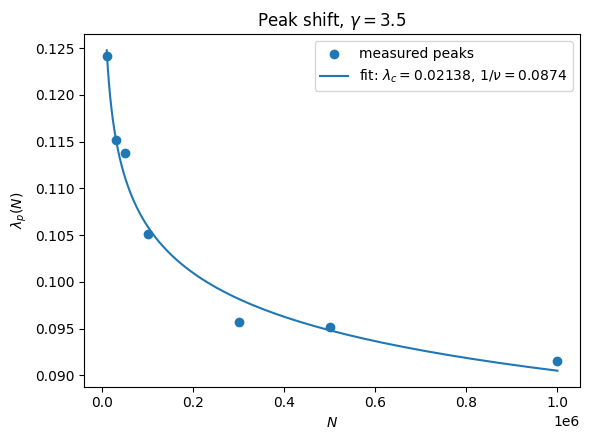

,gamma,N,lambda_p,tau_peak
0,3.5,10000,0.124111,2.272706
1,3.5,30000,0.115184,2.199789
2,3.5,50000,0.113821,2.214540
3,3.5,100000,0.105174,2.064284
4,3.5,300000,0.095702,1.933678
5,3.5,500000,0.095128,1.946150
6,3.5,1000000,0.091564,1.856364


,gamma,lambda_c,lambda_c_err,a,a_err,inv_nu,inv_nu_err
0,3.5,0.021378,0.094533,0.231233,0.015132,0.087398,0.097478


In [38]:

def parabolic_peak_estimate(x, y):
    """
    Estimate peak position and height by fitting a parabola to the maximum point
    and its two neighbors. Falls back to the discrete maximum at boundaries.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        idx = np.nanargmax(y)
        return x[idx], y[idx]

    order = np.argsort(x)
    x, y = x[order], y[order]
    idx = int(np.nanargmax(y))

    if idx == 0 or idx == len(x) - 1:
        return x[idx], y[idx]

    xs = x[idx - 1: idx + 2]
    ys = y[idx - 1: idx + 2]

    try:
        a, b, c = np.polyfit(xs, ys, 2)
        if a < 0:
            xp = -b / (2 * a)
            yp = a * xp * xp + b * xp + c
            if xs[0] <= xp <= xs[-1]:
                return float(xp), float(yp)
    except Exception:
        pass

    return float(x[idx]), float(y[idx])

def extract_peaks(results, gamma):
    rows = []
    sub = results[results["gamma"] == gamma].copy()

    for N, g in sub.groupby("N"):
        g = g.sort_values("lambda")
        xp, yp = parabolic_peak_estimate(g["lambda"].values, g["tau_mean"].values)
        rows.append({
            "gamma": gamma,
            "N": int(N),
            "lambda_p": xp,
            "tau_peak": yp,
        })
    return pd.DataFrame(rows).sort_values("N")

def lambda_peak_model(N, lambda_c, a, inv_nu):
    return lambda_c + a * N ** (-inv_nu)

def fit_lambda_c_from_peaks(peaks):
    N = peaks["N"].values.astype(float)
    lp = peaks["lambda_p"].values.astype(float)

    p0 = [lp[-1] * 0.9, lp[0] - lp[-1], 0.5]
    bounds = ([0.0, -np.inf, 0.01], [np.inf, np.inf, 5.0])

    popt, pcov = curve_fit(lambda_peak_model, N, lp, p0=p0, bounds=bounds, maxfev=100000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr, pcov

all_peak_rows = []
fit_summary = []

for gamma in sorted(results["gamma"].unique()) if not results.empty else []:
    peaks = extract_peaks(results, gamma)
    all_peak_rows.append(peaks)

    if len(peaks) >= 3:
        popt, perr, pcov = fit_lambda_c_from_peaks(peaks)
        lambda_c, a, inv_nu = popt
        lambda_c_err, a_err, inv_nu_err = perr
        fit_summary.append({
            "gamma": gamma,
            "lambda_c": lambda_c,
            "lambda_c_err": lambda_c_err,
            "a": a,
            "a_err": a_err,
            "inv_nu": inv_nu,
            "inv_nu_err": inv_nu_err,
        })

        N_plot = np.logspace(np.log10(peaks["N"].min()), np.log10(peaks["N"].max()), 200)
        plt.figure(figsize=(6, 4.5))
        plt.scatter(peaks["N"], peaks["lambda_p"], label="measured peaks")
        plt.plot(N_plot, lambda_peak_model(N_plot, *popt), label=rf"fit: $\lambda_c={lambda_c:.4g}$, $1/\nu={inv_nu:.3g}$")
        # plt.xscale("log")
        plt.xlabel(r"$N$")
        plt.ylabel(r"$\lambda_p(N)$")
        plt.title(rf"Peak shift, $\gamma={gamma}$")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"lambda_peak_fit_gamma{gamma}.png", dpi=200)
        plt.show()

peaks_df = pd.concat(all_peak_rows, ignore_index=True) if all_peak_rows else pd.DataFrame()
fit_df = pd.DataFrame(fit_summary)

display(peaks_df)
display(fit_df)

In [40]:
# Verificacio: lambda_c teoric de camp mitja a partir de la xarxa N=1e6 ja generada
gamma_check = 3.5
N_check = 1_000_000

graph_path_check = GRAPH_DIR / f"cm_gamma{gamma_check}_N{N_check}_kmin{KMIN}_cutoff{CUTOFF}_parallel{not REMOVE_PARALLEL}.npz"
indptr, indices, edge_ids, edge_u, edge_v, min_degree_nodes, realized_degree, meta = load_graph_npz(graph_path_check)

k_mean = realized_degree.mean()
k2_mean = (realized_degree.astype(float) ** 2).mean()
lambda_c_theory = k_mean / (k2_mean - k_mean)

print(f"<k>   = {k_mean:.4f}")
print(f"<k^2> = {k2_mean:.4f}")
print(f"lambda_c teoric (camp mitja, <k>/(<k^2>-<k>)) = {lambda_c_theory:.5f}")

<k>   = 6.2061
<k^2> = 65.1063
lambda_c teoric (camp mitja, <k>/(<k^2>-<k>)) = 0.10537


## 6. Estimació de $\gamma_1/\nu$ a partir de l'alçada del pic

A l'escala crítica, l'alçada del pic de la susceptibilitat del *lifespan* escala com:
$$
\langle\tau\rangle_{\rm peak}(N) \sim N^{\gamma_1/\nu}.
$$

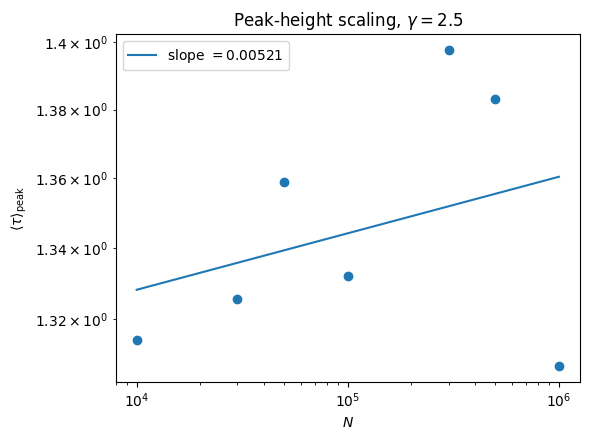

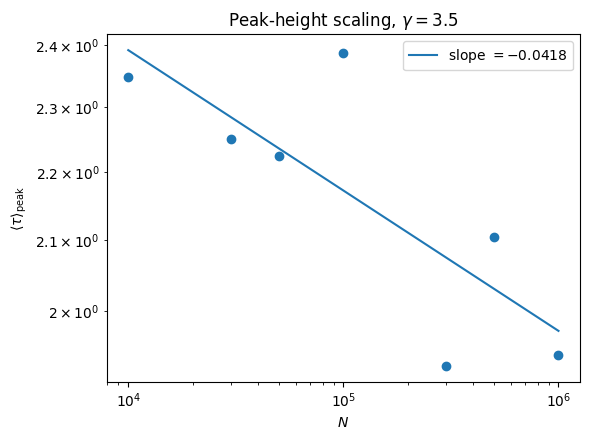

,gamma,gamma1_over_nu,intercept
0,2.5,0.005213,0.235768
1,3.5,-0.041795,1.256929


In [ ]:

def fit_power_law_N(N, y):
    N = np.asarray(N, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (N > 0) & (y > 0) & np.isfinite(y)
    xlog = np.log(N[mask])
    ylog = np.log(y[mask])
    coeff = np.polyfit(xlog, ylog, 1)
    slope, intercept = coeff[0], coeff[1]
    return slope, intercept

gamma1_rows = []

if not peaks_df.empty:
    for gamma, g in peaks_df.groupby("gamma"):
        slope, intercept = fit_power_law_N(g["N"], g["tau_peak"])
        gamma1_rows.append({"gamma": gamma, "gamma1_over_nu": slope, "intercept": intercept})

        N_plot = np.logspace(np.log10(g["N"].min()), np.log10(g["N"].max()), 200)
        plt.figure(figsize=(6, 4.5))
        plt.scatter(g["N"], g["tau_peak"])
        plt.plot(N_plot, np.exp(intercept) * N_plot ** slope, label=rf"slope $={slope:.3g}$")
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(r"$N$")
        plt.ylabel(r"$\langle\tau\rangle_{\rm peak}$")
        plt.title(rf"Peak-height scaling, $\gamma={gamma}$")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"tau_peak_height_gamma{gamma}.png", dpi=200)
        plt.show()

gamma1_df = pd.DataFrame(gamma1_rows)
display(gamma1_df)

## 7. Estimació de $\beta/\nu$ a partir de $P_{\rm end}(\lambda_c,N)$

A la criticalitat,
$$
P_{\rm end}(\lambda_c,N)\sim N^{-\beta/\nu}.
$$

Com que $\lambda_c$ en general no caurà exactament sobre la graella simulada, interpolem $P_{\rm end}(\lambda,N)$ per a cada mida.

In [ ]:

def interpolate_at_lambda(g, y_col, lambda_c):
    g = g.sort_values("lambda")
    x = g["lambda"].values.astype(float)
    y = g[y_col].values.astype(float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 2 or lambda_c < x.min() or lambda_c > x.max():
        return np.nan

    f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=np.nan)
    return float(f(lambda_c))

beta_rows = []
pendcrit_rows = []

for _, row in fit_df.iterrows() if not fit_df.empty else []:
    gamma = row["gamma"]
    lambda_c = row["lambda_c"]
    sub = results[results["gamma"] == gamma]

    rows = []
    for N, g in sub.groupby("N"):
        pc = interpolate_at_lambda(g, "P_end", lambda_c)
        rows.append({"gamma": gamma, "N": int(N), "lambda_c": lambda_c, "P_end_lambdac": pc})

    pc_df = pd.DataFrame(rows)
    pendcrit_rows.append(pc_df)

    valid = pc_df.dropna()
    valid = valid[(valid["P_end_lambdac"] > 0) & (valid["P_end_lambdac"] < 1)]

    if len(valid) >= 2:
        slope, intercept = fit_power_law_N(valid["N"], valid["P_end_lambdac"])
        beta_over_nu = -slope
        beta_rows.append({"gamma": gamma, "beta_over_nu": beta_over_nu, "intercept": intercept})

        N_plot = np.logspace(np.log10(valid["N"].min()), np.log10(valid["N"].max()), 200)
        plt.figure(figsize=(6, 4.5))
        plt.scatter(valid["N"], valid["P_end_lambdac"])
        plt.plot(N_plot, np.exp(intercept) * N_plot ** slope, label=rf"$\beta/\nu={beta_over_nu:.3g}$")
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(r"$N$")
        plt.ylabel(r"$P_{\rm end}(\lambda_c,N)$")
        plt.title(rf"Critical order-parameter scaling, $\gamma={gamma}$")
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"pend_lambdac_gamma{gamma}.png", dpi=200)
        plt.show()

pendcrit_df = pd.concat(pendcrit_rows, ignore_index=True) if pendcrit_rows else pd.DataFrame()
beta_df = pd.DataFrame(beta_rows)

display(pendcrit_df)
display(beta_df)

,gamma,N,lambda_c,P_end_lambdac
0,2.5,10000,1.606037e-03,NaN
1,2.5,30000,1.606037e-03,NaN
2,2.5,50000,1.606037e-03,NaN
3,2.5,100000,1.606037e-03,NaN
4,2.5,300000,1.606037e-03,NaN
5,2.5,500000,1.606037e-03,NaN
6,2.5,1000000,1.606037e-03,NaN
7,3.5,10000,3.744523e-07,NaN
8,3.5,30000,3.744523e-07,NaN
9,3.5,50000,3.744523e-07,NaN


""
